# Transfer Learning for Fungi Image Classification

Sorts 9,114 microscopy images of superficial fungal infections into five morphology classes. Five ImageNet backbones are frozen and used as fixed feature extractors under an identical trained head, so the comparison isolates the representation rather than the training budget. ResNet101 leads at 0.8476 test accuracy and VGG16 trails at 0.7862; class C2 is the hardest for every model.

**Data:** DeFungi; 9,114 images in five classes, resized to 224x224; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/773/defungi
Dataset citation: Vanegas Alvarez, Sopo, Pineda Sopo, Hajati, Gheisari.

## Models
| Model | Section | What it does |
|---|---|---|
| ResNet50 | Backbones | Frozen ImageNet backbone as a fixed feature extractor |
| ResNet101 | Backbones | Deeper residual variant |
| EfficientNetB0 | Backbones | Compound-scaled backbone, smallest parameter count |
| VGG16 | Backbones | Plain convolutional baseline, no residual connections |
| DenseNet201 | Backbones | Densely connected backbone |

Every backbone is frozen and trained under an identical head: global average pooling; a 256-unit ReLU layer with L2 regularization; batch normalization; 20% dropout; softmax over five classes. Adam optimizer, categorical cross entropy, early stopping on validation loss.

## Contents
| Section | What it covers |
|---|---|
| Class distribution | 9,114 images across five classes, one-hot encoded |
| Data split | Stratified 75/15/10 train, validation and test split, with images resized to 224x224 |
| Image augmentation | Random flip, rotation, zoom, translation, crop and contrast on the training set |
| Model head | Frozen backbone, global average pooling, a 256-unit ReLU layer with L2, batch normalization, 20% dropout, softmax output |
| Backbones | ResNet50, ResNet101, EfficientNetB0, VGG16 and DenseNet201, each trained identically |
| Training curves | Per-epoch loss and accuracy, with early stopping on validation loss at patience 10 |
| Test predictions | Per-class precision, recall and F1, with confusion matrices |
| Metric summary | Precision, recall, F1 and AUC across train, validation and test for all five models |

#### Import packages

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import os
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, roc_curve, auc, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.utils import load_img
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import resnet50, resnet, efficientnet, vgg16, densenet


### DeFungi Dataset

This project uses **DeFungi**,a dataset for direct mycological examination of microscopic fungi images. The images are from superficial fungal infections caused by yeasts, moulds, or dermatophyte fungi. The images have been manually labelled into five classes (C1 through C5) and images have been cropped with automated algorithms to produce the final dataset.

-  Source for data description:  https://archive.ics.uci.edu/dataset/773/defungi


## (b) Data Exploration and Pre-processing
#### Load Image Data Paths
Encode classes using one-hot encoding.

In [5]:
data_dir = "data/defungi"
img_paths = []
labels = []
class_names = sorted(os.listdir(data_dir))

for c in class_names:
    class_path = os.path.join(data_dir, c)
    for img in os.listdir(class_path):
        full_img_path = os.path.join(class_path, img)
        img_paths.append(full_img_path)
        labels.append(c)

df = pd.DataFrame({'label': labels, 'img_path': img_paths})
c_count = df['label'].value_counts()
print("Number of images in each class:")
print(c_count)

dummy_col = pd.get_dummies(df['label'], dtype=int)
df = pd.concat([df, dummy_col], axis=1)

display(df)

Number of images in each class:
label
C1    4404
C2    2334
C3     819
C4     818
C5     739
Name: count, dtype: int64


,label,img_path,C1,C2,C3,C4,C5
0,C1,/content/defungi/C1/H1_11b_8.jpg,1,0,0,0,0
1,C1,/content/defungi/C1/H1_30b_6.jpg,1,0,0,0,0
2,C1,/content/defungi/C1/H1_17b_4.jpg,1,0,0,0,0
3,C1,/content/defungi/C1/H1_101b_7.jpg,1,0,0,0,0
4,C1,/content/defungi/C1/H1_1c_12.jpg,1,0,0,0,0
...,...,...,...,...,...,...,...
9109,C5,/content/defungi/C5/H6_1b_6.jpg,0,0,0,0,1
9110,C5,/content/defungi/C5/H6_72a_20.jpg,0,0,0,0,1
9111,C5,/content/defungi/C5/H6_51a_1.jpg,0,0,0,0,1
9112,C5,/content/defungi/C5/H6_21a_6.jpg,0,0,0,0,1


####  i. Randomly divide each class into 75% training, 15% validation, and 10% test sets.


In [6]:
train_df, hold_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(hold_df, test_size=0.4, random_state=42, stratify=hold_df['label'])

counts_df = pd.DataFrame({
    'Train': train_df['label'].value_counts().sort_index(),
    'Validation': val_df['label'].value_counts().sort_index(),
    'Test': test_df['label'].value_counts().sort_index()
})
display(counts_df)

,Train,Validation,Test
label,,,
C1,3303,661,440
C2,1750,350,234
C3,614,123,82
C4,614,122,82
C5,554,111,74


#### ii. Load and resize images to 224×224, producing uniformly-shaped arrays

In [7]:
def get_img_arrays(df, size):
    X_list = []
    for path in df['img_path']:
        img = load_img(path, target_size=size)
        X_list.append(np.array(img))

    X = np.array(X_list, dtype=np.uint8)
    y = df[class_names].values.astype(np.float32)
    return X, y

resize_size = (224, 224)
X_train, y_train = get_img_arrays(train_df, resize_size)
X_val, y_val  = get_img_arrays(val_df, resize_size)
X_test, y_test = get_img_arrays(test_df, resize_size)

print("Array shapes:")
print("X_train:",X_train.shape, " y_train:", y_train.shape)
print("X_val:", X_val.shape, " y_val:", y_val.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

Array shapes:
X_train: (6835, 224, 224, 3)  y_train: (6835, 5)
X_val: (1367, 224, 224, 3)  y_val: (1367, 5)
X_test: (912, 224, 224, 3)  y_test: (912, 5)


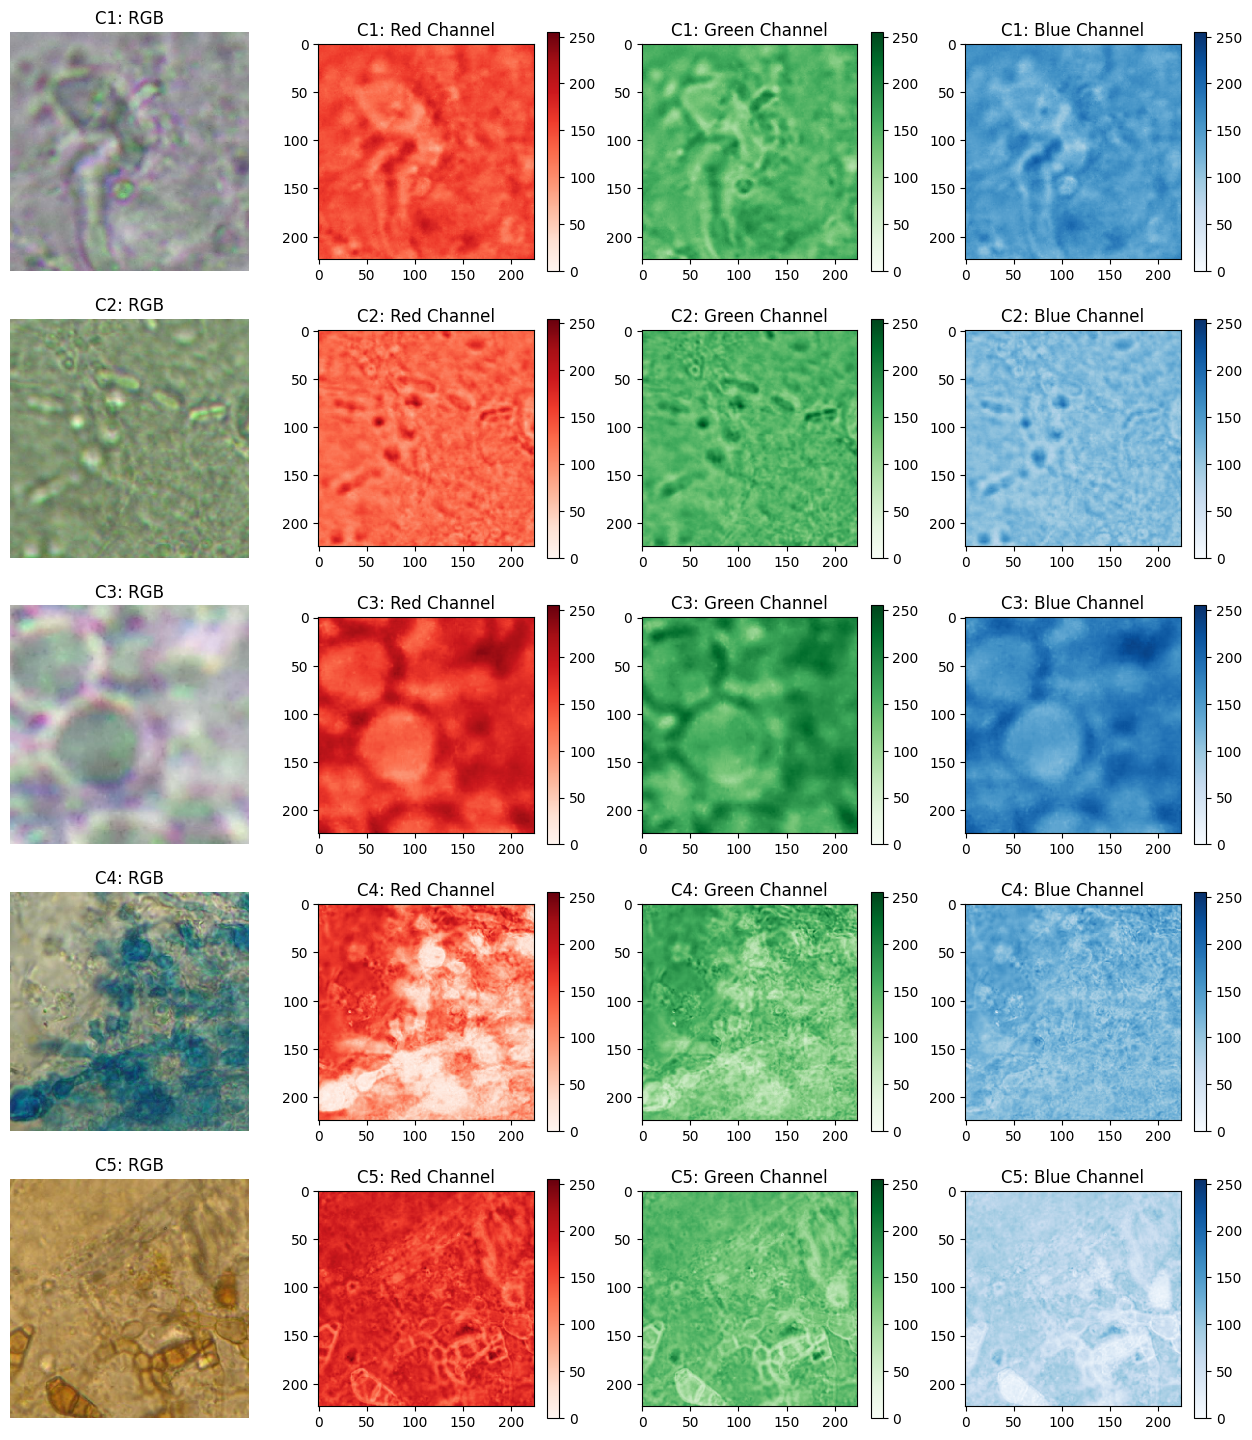

In [8]:
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
for row_id in range(5):
    class_name = class_names[row_id]
    match_id = []
    for i in range(len(y_train)):
        label = y_train[i]
        if label[row_id] == 1:
            match_id.append(i)

    pick_idx = np.random.choice(match_id)
    img = X_train[pick_idx]
    r_matrix, g_matrix, b_matrix = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    axes[row_id, 0].imshow(img)
    axes[row_id, 0].set_title(f"{class_name}: RGB")
    axes[row_id, 0].axis('off')

    red = axes[row_id, 1].imshow(r_matrix, cmap='Reds', vmin=0, vmax=255)
    axes[row_id, 1].set_title(f"{class_name}: Red Channel")
    plt.colorbar(red, ax=axes[row_id, 1])

    green = axes[row_id, 2].imshow(g_matrix, cmap='Greens', vmin=0, vmax=255)
    axes[row_id, 2].set_title(f"{class_name}: Green Channel")
    plt.colorbar(green, ax=axes[row_id, 2])

    blue = axes[row_id, 3].imshow(b_matrix, cmap='Blues', vmin=0, vmax=255)
    axes[row_id, 3].set_title(f"{class_name}: Blue Channel")
    plt.colorbar(blue, ax=axes[row_id, 3])
plt.show()

## (c) Transfer Learning
### ii. Define empirical regularization, crop, randomly zoom, rotate, flip, contrast, and translate images in your training set for image augmentation.

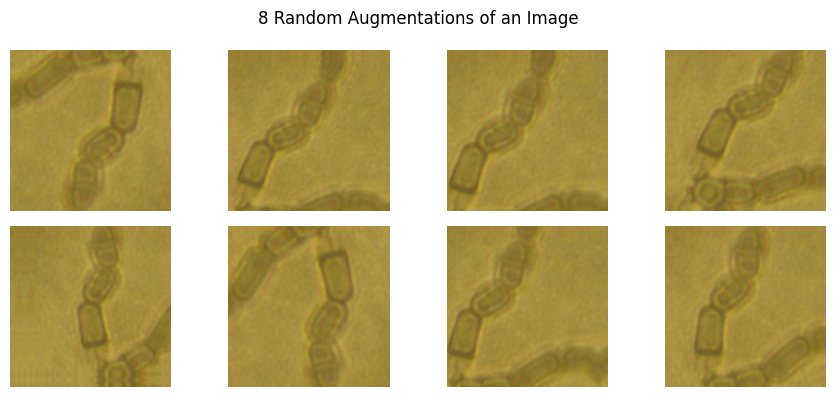

In [91]:
augment_img = Sequential([
    layers.Resizing(256, 256),
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomCrop(224, 224),
    layers.RandomContrast(0.1),
    ], name='augment_img')

ex_img = X_train[500:501]
fig, axes = plt.subplots(2, 4, figsize=(9, 4))
for ax in axes.flatten():
    aug = augment_img(ex_img, training=True)
    ax.imshow(np.clip(aug[0].numpy(), 0, 255).astype('uint8'))
    ax.axis('off')
plt.suptitle('8 Random Augmentations of an Image')
plt.tight_layout()
plt.show()

## Transfer-learning model

From parts i, iii, and iv we define following model: only the last layer is trained while all earlier layers are frozen, with the penultimate-layer output used as the features extracted from each image. The head uses ReLU activation, a softmax layer, L2 regularization, batch normalization, and a dropout rate of 20%, compiled with the ADAM optimizer and multinomial cross-entropy loss. The networks are trained for at least 50 epochs and up to 100, with patience of 10.

In [16]:
def get_CNN(base_CNN, preprocess_f):
    base_CNN.trainable = False
    input_base = tf.keras.Input(shape=(224, 224, 3))

    img = augment_img(input_base)
    img = preprocess_f(img)
    img = base_CNN(img, training=False)
    img = layers.GlobalAveragePooling2D()(img)
    img = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(img)
    img = layers.BatchNormalization()(img)
    img = layers.Dropout(0.2)(img)

    outputs = layers.Dense(5, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(img)
    spef_CNN = tf.keras.Model(input_base, outputs)
    spef_CNN.compile(optimizer=tf.keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    return spef_CNN

def early_stop():
    return tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, start_from_epoch = 50, verbose=1)


### ResNet50

In [17]:
tf.keras.utils.set_random_seed(42)
base_ResNet50 = resnet50.ResNet50(weights='imagenet', include_top=False)
model_ResNet50 = get_CNN(base_ResNet50, resnet50.preprocess_input)
store_ResNet50 = model_ResNet50.fit(X_train, y_train, batch_size= 32, validation_data=(X_val, y_val), epochs=100, callbacks=[early_stop()], verbose=2)

Epoch 1/100
214/214 - 17s - 78ms/step - accuracy: 0.6749 - loss: 0.9348 - val_accuracy: 0.7388 - val_loss: 0.7018
Epoch 2/100
214/214 - 6s - 30ms/step - accuracy: 0.7425 - loss: 0.6974 - val_accuracy: 0.7644 - val_loss: 0.6568
Epoch 3/100
214/214 - 6s - 30ms/step - accuracy: 0.7552 - loss: 0.6511 - val_accuracy: 0.7915 - val_loss: 0.6063
Epoch 4/100
214/214 - 6s - 30ms/step - accuracy: 0.7678 - loss: 0.6121 - val_accuracy: 0.7805 - val_loss: 0.6079
Epoch 5/100
214/214 - 6s - 30ms/step - accuracy: 0.7748 - loss: 0.5967 - val_accuracy: 0.8091 - val_loss: 0.5847
Epoch 6/100
214/214 - 6s - 30ms/step - accuracy: 0.7849 - loss: 0.5803 - val_accuracy: 0.8061 - val_loss: 0.5819
Epoch 7/100
214/214 - 6s - 30ms/step - accuracy: 0.7896 - loss: 0.5710 - val_accuracy: 0.7630 - val_loss: 0.6322
Epoch 8/100
214/214 - 6s - 30ms/step - accuracy: 0.7927 - loss: 0.5579 - val_accuracy: 0.8040 - val_loss: 0.5588
Epoch 9/100
214/214 - 6s - 30ms/step - accuracy: 0.7952 - loss: 0.5496 - val_accuracy: 0.7754 -

### ResNet101

In [18]:
tf.keras.utils.set_random_seed(42)
base_ResNet101 = resnet.ResNet101(weights='imagenet', include_top=False)
model_ResNet101 = get_CNN(base_ResNet101, resnet.preprocess_input)
store_ResNet101 = model_ResNet101.fit(X_train, y_train, batch_size=32, validation_data=(X_val, y_val), epochs=100, callbacks=[early_stop()], verbose=2)

Epoch 1/100
214/214 - 27s - 127ms/step - accuracy: 0.6705 - loss: 0.9559 - val_accuracy: 0.7271 - val_loss: 0.7381
Epoch 2/100
214/214 - 9s - 44ms/step - accuracy: 0.7330 - loss: 0.7131 - val_accuracy: 0.7630 - val_loss: 0.6755
Epoch 3/100
214/214 - 10s - 45ms/step - accuracy: 0.7517 - loss: 0.6676 - val_accuracy: 0.7688 - val_loss: 0.6247
Epoch 4/100
214/214 - 9s - 44ms/step - accuracy: 0.7661 - loss: 0.6270 - val_accuracy: 0.7762 - val_loss: 0.6244
Epoch 5/100
214/214 - 9s - 44ms/step - accuracy: 0.7703 - loss: 0.6170 - val_accuracy: 0.7849 - val_loss: 0.6290
Epoch 6/100
214/214 - 9s - 44ms/step - accuracy: 0.7778 - loss: 0.5986 - val_accuracy: 0.7901 - val_loss: 0.5952
Epoch 7/100
214/214 - 9s - 44ms/step - accuracy: 0.7764 - loss: 0.6009 - val_accuracy: 0.7952 - val_loss: 0.5931
Epoch 8/100
214/214 - 9s - 44ms/step - accuracy: 0.7835 - loss: 0.5858 - val_accuracy: 0.7886 - val_loss: 0.6025
Epoch 9/100
214/214 - 9s - 44ms/step - accuracy: 0.7892 - loss: 0.5689 - val_accuracy: 0.7747

### EfficientNetB0

In [19]:
tf.keras.utils.set_random_seed(42)
base_EfficientNetB0 = efficientnet.EfficientNetB0(weights='imagenet', include_top=False)
model_EfficientNetB0 = get_CNN(base_EfficientNetB0, efficientnet.preprocess_input)
store_EfficientNetB0 = model_EfficientNetB0.fit(X_train, y_train, batch_size=32, validation_data=(X_val, y_val), epochs=100, callbacks=[early_stop()], verbose=2)

Epoch 1/100
214/214 - 19s - 91ms/step - accuracy: 0.6511 - loss: 0.9953 - val_accuracy: 0.6759 - val_loss: 0.8248
Epoch 2/100
214/214 - 6s - 27ms/step - accuracy: 0.7081 - loss: 0.7639 - val_accuracy: 0.7169 - val_loss: 0.7587
Epoch 3/100
214/214 - 6s - 27ms/step - accuracy: 0.7263 - loss: 0.7203 - val_accuracy: 0.7388 - val_loss: 0.7107
Epoch 4/100
214/214 - 6s - 27ms/step - accuracy: 0.7340 - loss: 0.7016 - val_accuracy: 0.6898 - val_loss: 0.7794
Epoch 5/100
214/214 - 6s - 27ms/step - accuracy: 0.7432 - loss: 0.6787 - val_accuracy: 0.7293 - val_loss: 0.7338
Epoch 6/100
214/214 - 6s - 27ms/step - accuracy: 0.7469 - loss: 0.6781 - val_accuracy: 0.7469 - val_loss: 0.6872
Epoch 7/100
214/214 - 6s - 27ms/step - accuracy: 0.7523 - loss: 0.6539 - val_accuracy: 0.7396 - val_loss: 0.7272
Epoch 8/100
214/214 - 6s - 27ms/step - accuracy: 0.7504 - loss: 0.6555 - val_accuracy: 0.7454 - val_loss: 0.6786
Epoch 9/100
214/214 - 6s - 28ms/step - accuracy: 0.7549 - loss: 0.6426 - val_accuracy: 0.7476 -

### VGG16

In [20]:
tf.keras.utils.set_random_seed(42)
base_VGG16 = vgg16.VGG16(weights='imagenet', include_top=False)
model_VGG16 = get_CNN(base_VGG16, vgg16.preprocess_input)
store_VGG16 = model_VGG16.fit(X_train, y_train, batch_size=32, validation_data=(X_val, y_val), epochs=100, callbacks=[early_stop()], verbose=2)

Epoch 1/100
214/214 - 9s - 42ms/step - accuracy: 0.6337 - loss: 1.0393 - val_accuracy: 0.6745 - val_loss: 0.8691
Epoch 2/100
214/214 - 6s - 27ms/step - accuracy: 0.7018 - loss: 0.7940 - val_accuracy: 0.7037 - val_loss: 0.7502
Epoch 3/100
214/214 - 6s - 27ms/step - accuracy: 0.7208 - loss: 0.7330 - val_accuracy: 0.7059 - val_loss: 0.7595
Epoch 4/100
214/214 - 6s - 27ms/step - accuracy: 0.7181 - loss: 0.7162 - val_accuracy: 0.6964 - val_loss: 0.7657
Epoch 5/100
214/214 - 6s - 27ms/step - accuracy: 0.7386 - loss: 0.6777 - val_accuracy: 0.7132 - val_loss: 0.7529
Epoch 6/100
214/214 - 6s - 27ms/step - accuracy: 0.7421 - loss: 0.6679 - val_accuracy: 0.7015 - val_loss: 0.8033
Epoch 7/100
214/214 - 6s - 27ms/step - accuracy: 0.7504 - loss: 0.6547 - val_accuracy: 0.7271 - val_loss: 0.7286
Epoch 8/100
214/214 - 6s - 27ms/step - accuracy: 0.7486 - loss: 0.6508 - val_accuracy: 0.7059 - val_loss: 0.7457
Epoch 9/100
214/214 - 6s - 27ms/step - accuracy: 0.7536 - loss: 0.6368 - val_accuracy: 0.7154 - 

### DenseNet201

In [21]:
tf.keras.utils.set_random_seed(42)
base_DenseNet201 = densenet.DenseNet201(weights='imagenet', include_top=False)
model_DenseNet201 = get_CNN(base_DenseNet201, densenet.preprocess_input)
store_DenseNet201 = model_DenseNet201.fit(X_train, y_train, batch_size=32, validation_data=(X_val, y_val), epochs=100, callbacks=[early_stop()], verbose=2)

Epoch 1/100
214/214 - 42s - 195ms/step - accuracy: 0.6634 - loss: 0.9360 - val_accuracy: 0.7257 - val_loss: 0.7539
Epoch 2/100
214/214 - 12s - 58ms/step - accuracy: 0.7160 - loss: 0.7121 - val_accuracy: 0.7484 - val_loss: 0.6669
Epoch 3/100
214/214 - 12s - 58ms/step - accuracy: 0.7343 - loss: 0.6717 - val_accuracy: 0.7462 - val_loss: 0.6767
Epoch 4/100
214/214 - 12s - 58ms/step - accuracy: 0.7463 - loss: 0.6455 - val_accuracy: 0.7425 - val_loss: 0.6846
Epoch 5/100
214/214 - 12s - 58ms/step - accuracy: 0.7544 - loss: 0.6405 - val_accuracy: 0.7593 - val_loss: 0.6271
Epoch 6/100
214/214 - 13s - 58ms/step - accuracy: 0.7535 - loss: 0.6311 - val_accuracy: 0.7440 - val_loss: 0.6812
Epoch 7/100
214/214 - 12s - 58ms/step - accuracy: 0.7639 - loss: 0.6105 - val_accuracy: 0.7469 - val_loss: 0.7591
Epoch 8/100
214/214 - 13s - 59ms/step - accuracy: 0.7627 - loss: 0.6098 - val_accuracy: 0.7586 - val_loss: 0.6411
Epoch 9/100
214/214 - 12s - 57ms/step - accuracy: 0.7669 - loss: 0.5983 - val_accuracy:

### Training Report for 5 Models

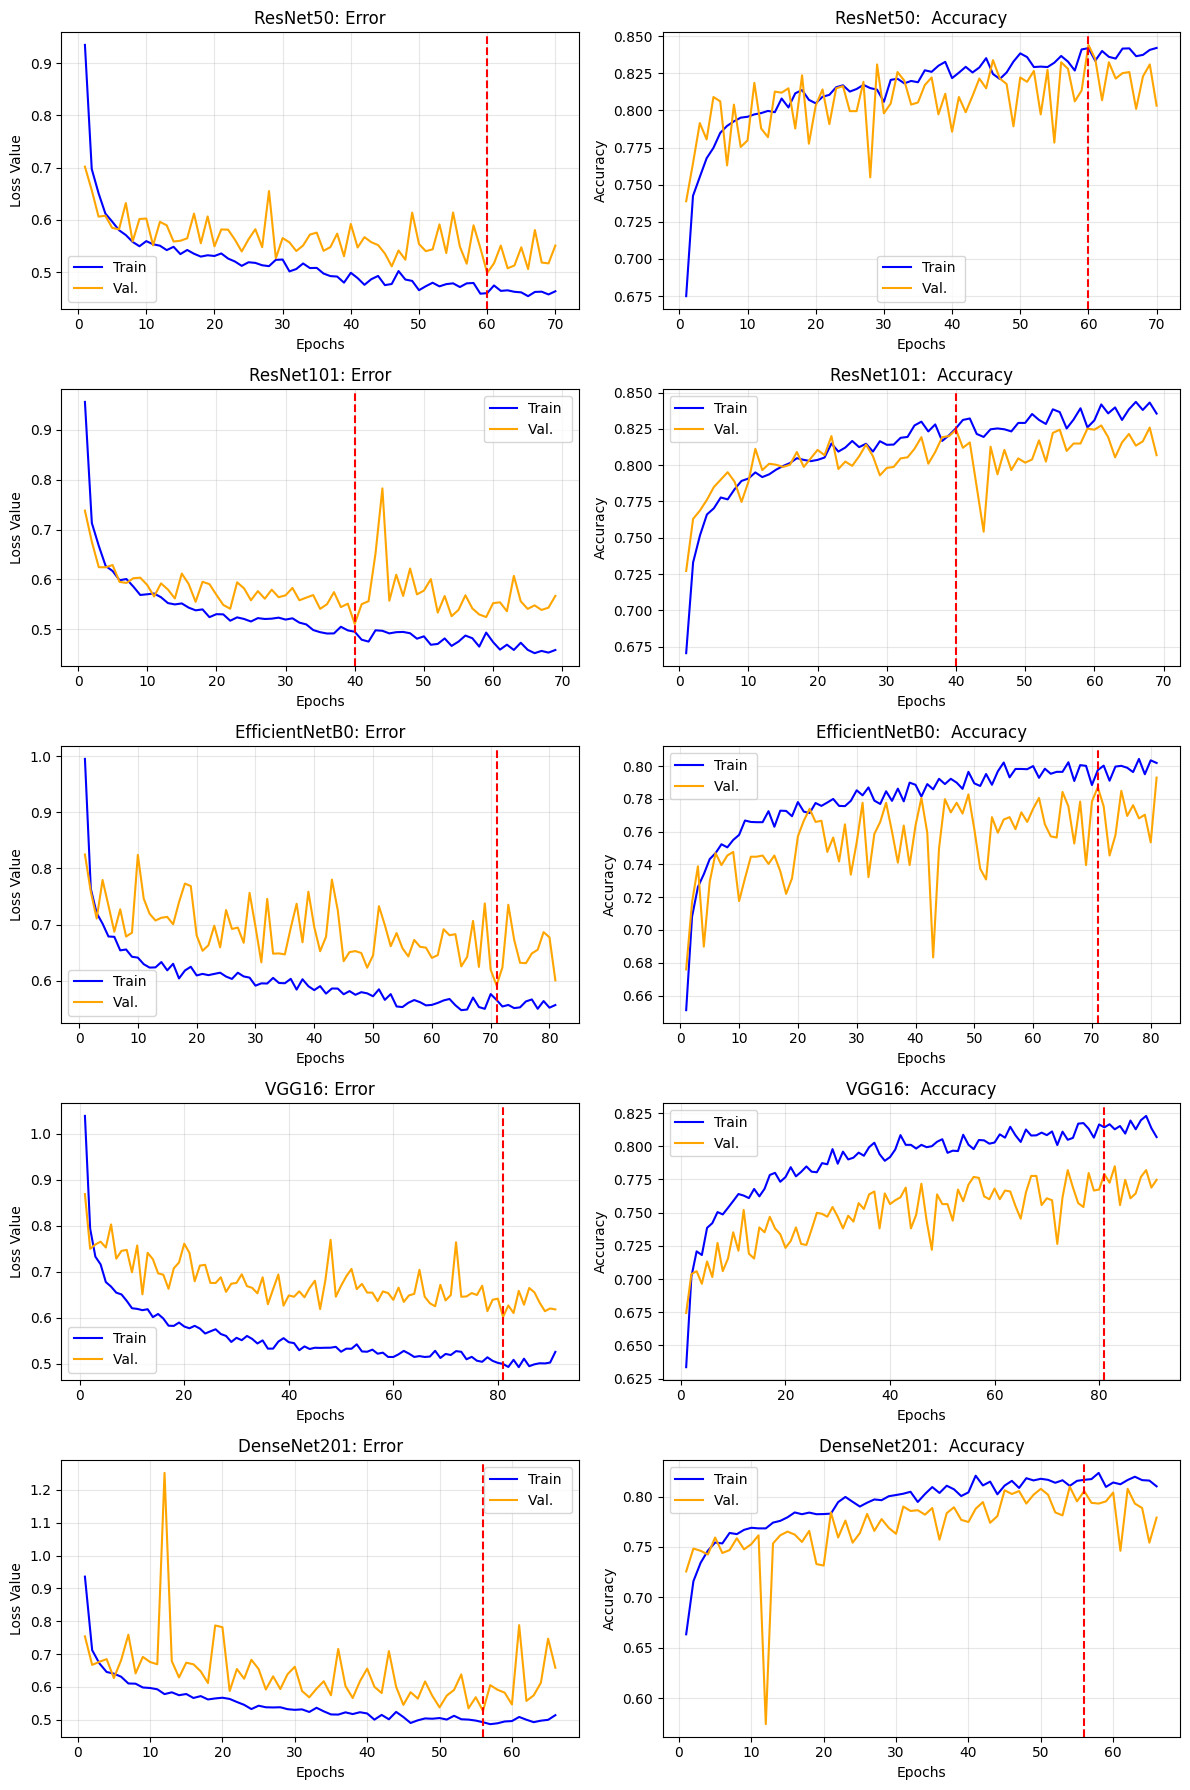

,Model,Best Epoch,Val Loss,Val Accuracy
0,ResNet50,60,0.4985,0.8442
1,ResNet101,40,0.5110,0.8244
2,EfficientNetB0,71,0.5916,0.7871
3,VGG16,81,0.6020,0.7791
4,DenseNet201,56,0.5266,0.8054


In [40]:
models = [
("ResNet50", store_ResNet50),
("ResNet101", store_ResNet101),
("EfficientNetB0", store_EfficientNetB0),
("VGG16", store_VGG16),
("DenseNet201", store_DenseNet201)
]

best_rows = []
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
for row_index, (par, values) in enumerate(models):
    train_loss = values.history['loss']
    val_loss = values.history['val_loss']
    train_acc = values.history['accuracy']
    val_acc = values.history['val_accuracy']

    total_epo = len(train_loss)
    epoch_num = range(1, total_epo + 1)
    best_epo_idx = np.argmin(val_loss)
    best_epo_num = best_epo_idx + 1

    best_rows.append({ 'Model': par, 'Best Epoch': best_epo_num, 'Val Loss': val_loss[best_epo_idx], 'Val Accuracy': val_acc[best_epo_idx]})

    ax_loss = axes[row_index, 0]
    ax_loss.plot(epoch_num, train_loss, label='Train ', color='blue')
    ax_loss.plot(epoch_num, val_loss, label='Val. ', color='orange')
    ax_loss.axvline(x=best_epo_num, color='red', linestyle='--')
    ax_loss.set_title(f"{par}: Error")
    ax_loss.set_xlabel("Epochs")
    ax_loss.set_ylabel("Loss Value")
    ax_loss.legend()

    ax_loss.grid(True, alpha=0.3)
    ax_acc = axes[row_index, 1]
    ax_acc.plot(epoch_num, train_acc, label='Train ', color='blue')
    ax_acc.plot(epoch_num, val_acc, label='Val. ', color='orange')
    ax_acc.axvline(x=best_epo_num, color='red', linestyle='--')
    ax_acc.set_title(f"{par}:  Accuracy")
    ax_acc.set_xlabel("Epochs")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

train_sum = pd.DataFrame(best_rows).round(4)
display(train_sum)

### Get Predictions for 5 Models

In [44]:
y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

def get_predict(model):
    p_train = model.predict(X_train, verbose=0)
    p_val = model.predict(X_val, verbose=0)
    p_test = model.predict(X_test, verbose=0)
    c_train = np.argmax(p_train, axis=1)
    c_val = np.argmax(p_val, axis=1)
    c_test = np.argmax(p_test, axis=1)

    outputs = {
        'p_train': p_train,
        'p_val': p_val,
        'p_test': p_test,
        'c_train': c_train,
        'c_val': c_val,
        'c_test': c_test
    }

    return outputs

pred_dir = {
    'ResNet50': get_predict(model_ResNet50),
    'ResNet101': get_predict(model_ResNet101),
    'EfficientNetB0': get_predict(model_EfficientNetB0),
    'VGG16': get_predict(model_VGG16),
    'DenseNet201': get_predict(model_DenseNet201),
  }


 ResNet50: Test Set
              precision    recall  f1-score   support

          C1     0.8483    0.9023    0.8744       440
          C2     0.7801    0.6368    0.7012       234
          C3     0.7048    0.9024    0.7914        82
          C4     1.0000    0.8537    0.9211        82
          C5     0.8974    0.9459    0.9211        74

    accuracy                         0.8333       912
   macro avg     0.8461    0.8482    0.8418       912
weighted avg     0.8355    0.8333    0.8305       912



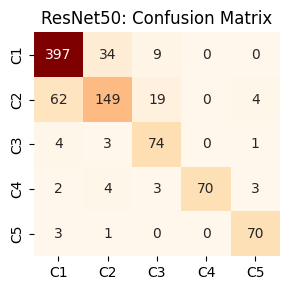


 ResNet101: Test Set
              precision    recall  f1-score   support

          C1     0.8306    0.9364    0.8803       440
          C2     0.8051    0.6709    0.7319       234
          C3     0.8571    0.8049    0.8302        82
          C4     1.0000    0.8415    0.9139        82
          C5     0.9200    0.9324    0.9262        74

    accuracy                         0.8476       912
   macro avg     0.8826    0.8372    0.8565       912
weighted avg     0.8490    0.8476    0.8445       912



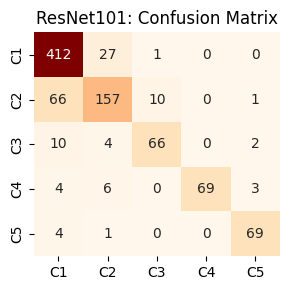


 EfficientNetB0: Test Set
              precision    recall  f1-score   support

          C1     0.8082    0.8909    0.8476       440
          C2     0.6740    0.6538    0.6638       234
          C3     0.9194    0.6951    0.7917        82
          C4     1.0000    0.7927    0.8844        82
          C5     0.9041    0.8919    0.8980        74

    accuracy                         0.8037       912
   macro avg     0.8611    0.7849    0.8171       912
weighted avg     0.8088    0.8037    0.8028       912



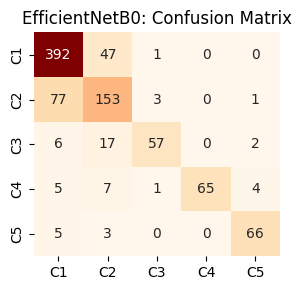


 VGG16: Test Set
              precision    recall  f1-score   support

          C1     0.7429    0.9523    0.8347       440
          C2     0.8042    0.4915    0.6101       234
          C3     0.7879    0.6341    0.7027        82
          C4     0.9315    0.8293    0.8774        82
          C5     0.9545    0.8514    0.9000        74

    accuracy                         0.7862       912
   macro avg     0.8442    0.7517    0.7850       912
weighted avg     0.7968    0.7862    0.7743       912



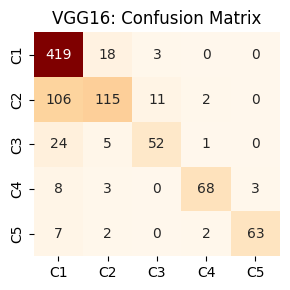


 DenseNet201: Test Set
              precision    recall  f1-score   support

          C1     0.8144    0.8977    0.8541       440
          C2     0.7268    0.6368    0.6788       234
          C3     0.7927    0.7927    0.7927        82
          C4     0.9851    0.8049    0.8859        82
          C5     0.9315    0.9189    0.9252        74

    accuracy                         0.8147       912
   macro avg     0.8501    0.8102    0.8273       912
weighted avg     0.8148    0.8147    0.8122       912



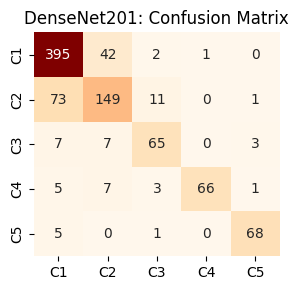

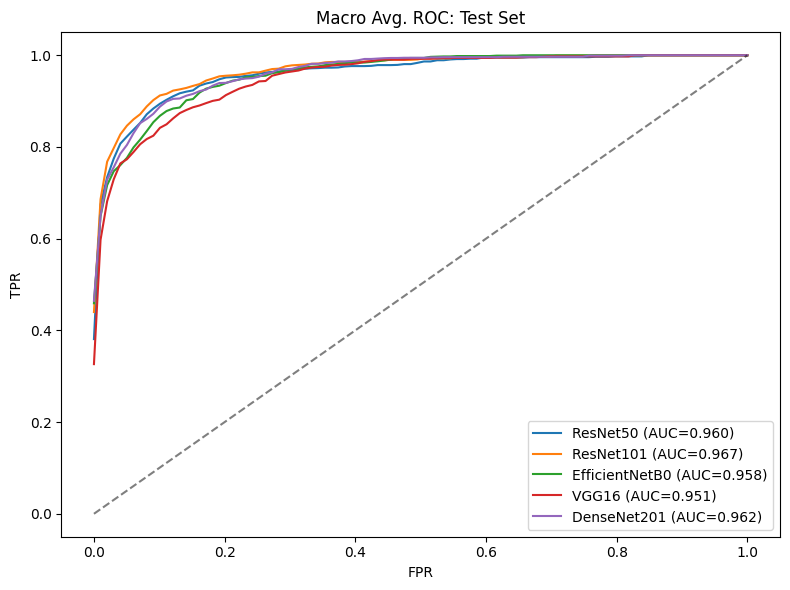

In [75]:
for model, p in pred_dir.items():
    print(f'\n {model}: Test Set')
    print(classification_report(y_test_labels, p['c_test'], target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_test_labels, p['c_test'])
    fig, ax = plt.subplots(figsize=(3, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f'{model}: Confusion Matrix')
    plt.tight_layout()
    plt.show()

print('\n')
plt.figure(figsize=(8, 6))
for model, p in pred_dir.items():
    fpr_grid = np.linspace(0, 1, 100)
    tprs = []
    for class_idx in range(5):
        fpr, tpr, _ = roc_curve(y_test[:, class_idx], p['p_test'][:, class_idx])
        tprs.append(np.interp(fpr_grid, fpr, tpr))
    macro_tpr = np.mean(tprs, axis=0)
    plt.plot(fpr_grid, macro_tpr, label=f'{model} (AUC={auc(fpr_grid, macro_tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Macro Avg. ROC: Test Set')
plt.legend()
plt.tight_layout()
plt.show()


### Final Scores for 5 Models: Train, Validation, and Test Sets

In [84]:
def get_metrics(y_true_c, y_true_p, y_pred_c, y_pred_p):
    prec = precision_score(y_true_c, y_pred_c, average='macro', zero_division=0)
    rec = recall_score(y_true_c, y_pred_c, average='macro', zero_division=0)
    f1 = f1_score(y_true_c, y_pred_c, average='macro', zero_division=0)
    auc = roc_auc_score(y_true_p, y_pred_p, multi_class='ovr')
    return prec, rec, f1, auc

report_metrics = []

for model, p in pred_dir.items():
    p_tr, r_tr, f1_tr, auc_tr = get_metrics(y_train_labels, y_train, p['c_train'], p['p_train'])
    report_metrics.append({'Model': model, 'Set': 'Train', 'Precision': p_tr, 'Recall': r_tr, 'F1': f1_tr, 'AUC': auc_tr})

    p_v, r_v, f1_v, auc_v = get_metrics(y_val_labels, y_val, p['c_val'], p['p_val'])
    report_metrics.append({'Model': model, 'Set': 'Val', 'Precision': p_v, 'Recall': r_v, 'F1': f1_v, 'AUC': auc_v})

    p_te, r_te, f1_te, auc_te = get_metrics(y_test_labels, y_test, p['c_test'], p['p_test'])
    report_metrics.append({'Model': model, 'Set': 'Test', 'Precision': p_te, 'Recall': r_te, 'F1': f1_te, 'AUC': auc_te})

metrics_df = pd.DataFrame(report_metrics)
display(metrics_df.style.hide(axis='index'))

Model,Set,Precision,Recall,F1,AUC
ResNet50,Train,0.899822,0.900839,0.898208,0.978882
ResNet50,Val,0.868471,0.850843,0.858271,0.958814
ResNet50,Test,0.846119,0.848214,0.841835,0.961127
ResNet101,Train,0.917677,0.868952,0.889403,0.980351
ResNet101,Val,0.877741,0.811416,0.837932,0.959077
ResNet101,Test,0.882583,0.837216,0.856509,0.967474
EfficientNetB0,Train,0.884235,0.825099,0.850623,0.966416
EfficientNetB0,Val,0.862378,0.770776,0.807332,0.944736
EfficientNetB0,Test,0.861144,0.784890,0.817064,0.958586
VGG16,Train,0.895712,0.805933,0.838732,0.966373


### Interpretation: Does a model clearly outperform the others?

Across all 5 models, training accuracy and validation accuracy gaind a lot during the first 2-4 epochs, then flattened into witheach next epoch contributed minor improvements. This is can be attributed to transfer learning with our frozen pretrained base, where head learned most of the class-distinct information very early. Despite the early flattening, all 5 models achieved substantial accuracy on the test set, with macro F1 scores ranging from 0.785 to 0.898.

Confusion matrices shows ResNet101 is strongest on predtciong four classes (C1, C2, C3, C5), losing only C4 to ResNet50. While VGG16 ranks last on every class. Also class C2 is the hardest to predict across every model.

Overall ResNet101 outperformed the other four pre-trained models on the test set, leading on three of the four metrics: precision 0.883, F1 0.857, and AUC 0.968. ResNet50 has marginally higher recall (0.848 vs 0.837) but weaker on the all other metrics, making it the second-best model. DenseNet201 and EfficientNetB0 are next best models and VGG16 ranks last. Addtinly ResNet101 shows the best generalization, since with smallest train-to-test F1 gap.

### References:
-  https://archive-beta.ics.uci.edu/dataset/773/defungi
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://numpy.org/devdocs/reference/arrays.dtypes.html
- https://www.tensorflow.org/api_docs/python/tf/keras/utils/load_img
- https://www.tensorflow.org/tutorials/images/data_augmentation
- https://www.tensorflow.org/api_docs/python/tf/keras/Model
- https://www.tensorflow.org/api_docs/python/tf/keras/activations
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense
- https://www.tensorflow.org/api_docs/python/tf/keras/activations/relu
- https://www.tensorflow.org/api_docs/python/tf/keras/regularizers/L2
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout
- https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam
- https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy
- https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping
- https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- https://seaborn.pydata.org/generated/seaborn.heatmap.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html


